## 1. Imports

In [1]:
import copy
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.nn.init import xavier_uniform_
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')


In [2]:

MU_BETA_BASE  = 0.959
SIGMA_BETA    = 0.3
MU_GAMMA_BASE = 0.002
SIGMA_GAMMA   = 0.3

lambda1 = 0.8
lambda2 = 0.111
lambda3 = 0.009

#Training hyperparameters
EPOCHS      = 3000      
HIDDEN_DIMS = [50, 50, 50]
BATCH_SIZE  = 32
LR          = 1e-3
BETA0_INIT, GAMMA0_INIT = 1.0, 1.0

SEEDS = [42,7,123]  

N_PARAMS_PIPINN = 2  

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device          : {device}')
print(f'Seeds (n={len(SEEDS)})     : {SEEDS}')
print(f'Prior (PI-PINN) : mu_beta={MU_BETA_BASE}, sigma_beta={SIGMA_BETA}, '
      f'mu_gamma={MU_GAMMA_BASE}, sigma_gamma={SIGMA_GAMMA}')


Device          : cpu
Seeds (n=3)     : [42, 7, 123]
Prior (PI-PINN) : mu_beta=0.959, sigma_beta=0.3, mu_gamma=0.002, sigma_gamma=0.3


In [3]:
def load_and_prepare_data(test_frac=0.1, val_frac=0.1,
                          csv_path='dengue_srilanka_2017.csv'):

    data_loaded = pd.read_csv(csv_path)
    data_loaded = data_loaded.sort_values('time').reset_index(drop=True)

    t_all = data_loaded['time'].values.reshape(-1, 1)
    S_all = data_loaded['Susceptible'].values.reshape(-1, 1)
    I_all = data_loaded['Infected'].values.reshape(-1, 1)
    R_all = data_loaded['Recovered'].values.reshape(-1, 1)

    n       = len(data_loaded)
    n_test  = max(1, int(round(n * test_frac)))
    n_val   = max(1, int(round(n * val_frac)))
    n_train = n - n_test - n_val

    train_sl = slice(0, n_train)
    val_sl   = slice(n_train, n_train + n_val)
    test_sl  = slice(n_train + n_val, n)

    return (
        t_all[train_sl],  t_all[val_sl],  t_all[test_sl],
        S_all[train_sl],  I_all[train_sl], R_all[train_sl],
        S_all[val_sl],    I_all[val_sl],   R_all[val_sl],
        S_all[test_sl],   I_all[test_sl],  R_all[test_sl]
    )


(t_train_set,      t_val_set,       t_test_set,
 data_S_train_set, data_I_train_set, data_R_train_set,
 data_S_val_set,   data_I_val_set,   data_R_val_set,
 data_S_test_set,  data_I_test_set,  data_R_test_set) = load_and_prepare_data()

n_test_points = t_test_set.shape[0]
print(f'Train: {t_train_set.shape[0]} | Val: {t_val_set.shape[0]} | Test: {n_test_points}')
print(f'Time range -> train: [{t_train_set.min():.0f}, {t_train_set.max():.0f}]  '
      f'val: [{t_val_set.min():.0f}, {t_val_set.max():.0f}]  '
      f'test: [{t_test_set.min():.0f}, {t_test_set.max():.0f}]')


Train: 41 | Val: 5 | Test: 5
Time range -> train: [0, 40]  val: [41, 45]  test: [46, 50]


In [4]:
def to_tensor(x, device, requires_grad=False):
    return torch.tensor(x, dtype=torch.float32, requires_grad=requires_grad).to(device)


def prepare_dataloader(t, S, I, R, batch_size, device):
    dataset = TensorDataset(
        to_tensor(t, device, requires_grad=True),
        to_tensor(S, device),
        to_tensor(I, device),
        to_tensor(R, device)
    )
    return DataLoader(dataset, batch_size=batch_size, shuffle=True)


t_val_tensor   = to_tensor(t_val_set, device)
S_val_tensor   = to_tensor(data_S_val_set, device)
I_val_tensor   = to_tensor(data_I_val_set, device)
R_val_tensor   = to_tensor(data_R_val_set, device)

t_test_tensor  = to_tensor(t_test_set, device)
S_test_np, I_test_np, R_test_np = data_S_test_set, data_I_test_set, data_R_test_set

print('All shared tensors ready.')


All shared tensors ready.


In [5]:
class PIPINN(nn.Module):

    def __init__(self, input_dim=1, hidden_dims=(50, 50, 50), output_dim=3,
                 beta_init=1.0, gamma_init=1.0):
        super().__init__()
        layers = []
        in_dim = input_dim
        for h in hidden_dims:
            layers += [nn.Linear(in_dim, h), nn.Tanh()]
            in_dim = h
        layers += [nn.Linear(in_dim, output_dim)]
        self.network = nn.Sequential(*layers)

        for layer in self.network:
            if isinstance(layer, nn.Linear):
                xavier_uniform_(layer.weight)
                nn.init.constant_(layer.bias, 0)

        self.params = nn.ParameterDict({
            'beta' : nn.Parameter(torch.tensor(float(beta_init))),
            'gamma': nn.Parameter(torch.tensor(float(gamma_init)))
        })

    def forward(self, t):
        return self.network(t)   # columns: [S, I, R]


print('PIPINN model class defined.')


PIPINN model class defined.


In [6]:
def train_pipinn(model, optimizer, train_loader,
                  t_val_tensor, S_val_tensor, I_val_tensor, R_val_tensor,
                  mu_beta_prior, sigma_beta_prior, mu_gamma_prior, sigma_gamma_prior,
                  epochs=EPOCHS, lambda1=lambda1, lambda2=lambda2, lambda3=lambda3, verbose=True):
    
    train_losses, val_losses = [], []
    parameter_estimates = {'beta': [], 'gamma': []}
    best_val_loss = float('inf')
    epochs_without_improvement = 0
    best_model_state = None

    for epoch in range(epochs):
        model.train()
        epoch_batch_losses = []

        for t_batch, S_batch, I_batch, R_batch in train_loader:
            optimizer.zero_grad()
            t_batch = t_batch.requires_grad_(True)

            output = model(t_batch)
            S_pred, I_pred, R_pred = output[:, 0:1], output[:, 1:2], output[:, 2:3]
            beta, gamma = model.params['beta'], model.params['gamma']

            dS_dt = torch.autograd.grad(S_pred, t_batch, grad_outputs=torch.ones_like(S_pred), create_graph=True)[0]
            dI_dt = torch.autograd.grad(I_pred, t_batch, grad_outputs=torch.ones_like(I_pred), create_graph=True)[0]
            dR_dt = torch.autograd.grad(R_pred, t_batch, grad_outputs=torch.ones_like(R_pred), create_graph=True)[0]

            physics_loss = (torch.mean((dS_dt + beta * S_pred * I_pred) ** 2) +
                             torch.mean((dI_dt - beta * S_pred * I_pred + gamma * I_pred) ** 2) +
                             torch.mean((dR_dt - gamma * I_pred) ** 2))
            data_loss = (torch.mean((S_pred - S_batch) ** 2) +
                         torch.mean((I_pred - I_batch) ** 2) +
                         torch.mean((R_pred - R_batch) ** 2))


            # data_loss = (torch.mean((S_pred - S_batch) ** 2) / (S_batch.var() + 1e-8) +
            #               torch.mean((I_pred - I_batch) ** 2) / (I_batch.var() + 1e-8) +
            #               torch.mean((R_pred - R_batch) ** 2) / (R_batch.var() + 1e-8))
            
            prior_loss = ((beta  - mu_beta_prior)  ** 2 / (2 * sigma_beta_prior  ** 2) +
                          (gamma - mu_gamma_prior) ** 2 / (2 * sigma_gamma_prior ** 2))

            loss = lambda2 * physics_loss + lambda1 * data_loss + lambda3 * prior_loss
            loss.backward()
            optimizer.step()
            epoch_batch_losses.append(loss.item())

        train_losses.append(np.mean(epoch_batch_losses))
        parameter_estimates['beta'].append(beta.item())
        parameter_estimates['gamma'].append(gamma.item())

        # ---- Validation ----
        model.eval()
        with torch.no_grad():
            out_val = model(t_val_tensor)
            val_loss = (torch.mean((out_val[:, 0:1] - S_val_tensor) ** 2) +
                        torch.mean((out_val[:, 1:2] - I_val_tensor) ** 2) +
                        torch.mean((out_val[:, 2:3] - R_val_tensor) ** 2)).item()
            val_losses.append(val_loss)

        # ---- Best-model checkpointing (no early stopping, just tracking) ----
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = copy.deepcopy(model.state_dict())
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epoch % 500 == 0:
            print(f'  Epoch {epoch:5d} | beta={beta.item():.4f} gamma={gamma.item():.5f} | '
                  f'train={train_losses[-1]:.6f} val={val_loss:.6f}')

    # ---- Restore best-validation weights ----
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        if verbose:
            print(f'Restored best model state (val_loss={best_val_loss:.6f}).')

    return train_losses, val_losses, parameter_estimates, best_val_loss


print('train_pipinn defined.')


train_pipinn defined.


## 7. Run Training

In [7]:
seed = SEEDS[0]
torch.manual_seed(seed)
np.random.seed(seed)

print(f'Running PI-PINN training with seed={seed}')
print('-' * 60)

train_loader = prepare_dataloader(t_train_set, data_S_train_set, data_I_train_set,
                                   data_R_train_set, BATCH_SIZE, device)

pipinn_model = PIPINN(input_dim=1, hidden_dims=HIDDEN_DIMS, output_dim=3,
                       beta_init=BETA0_INIT, gamma_init=GAMMA0_INIT).to(device)

optimizer = optim.Adam(
    list(pipinn_model.network.parameters()) + list(pipinn_model.params.values()),
    lr=LR
)

train_losses, val_losses, parameter_estimates, best_val_loss = train_pipinn(
    pipinn_model, optimizer, train_loader,
    t_val_tensor, S_val_tensor, I_val_tensor, R_val_tensor,
    MU_BETA_BASE, SIGMA_BETA, MU_GAMMA_BASE, SIGMA_GAMMA,
    epochs=EPOCHS, verbose=True
)

print('\nTraining complete.')
print(f'Final estimates -> beta={parameter_estimates["beta"][-1]:.4f}, '
      f'gamma={parameter_estimates["gamma"][-1]:.4f}')


Running PI-PINN training with seed=42
------------------------------------------------------------
  Epoch     0 | beta=0.9980 gamma=0.99800 | train=4.595130 val=3.538546
  Epoch   500 | beta=0.9590 gamma=0.26524 | train=0.003533 val=0.000182
  Epoch  1000 | beta=0.9590 gamma=0.02404 | train=0.000066 val=0.000183
  Epoch  1500 | beta=0.9589 gamma=0.00228 | train=0.000045 val=0.000107
  Epoch  2000 | beta=0.9589 gamma=0.00207 | train=0.000030 val=0.000050
  Epoch  2500 | beta=0.9589 gamma=0.00206 | train=0.000033 val=0.000137
Restored best model state (val_loss=0.000002).

Training complete.
Final estimates -> beta=0.9589, gamma=0.0021


In [8]:
def r_squared(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - ss_res / ss_tot if ss_tot > 0 else float('nan')


def aic_bic(rmse, n, k):
    
    rmse = max(rmse, 1e-12)
    aic = n * np.log(rmse ** 2) + 2 * k
    bic = n * np.log(rmse ** 2) + k * np.log(n)
    return aic, bic


def evaluate_pipinn(model, t_test_tensor, S_test_np, I_test_np, R_test_np, n_params=N_PARAMS_PIPINN):
    model.eval()
    with torch.no_grad():
        out_test = model(t_test_tensor)
        S_pred = out_test[:, 0:1].cpu().numpy()
        I_pred = out_test[:, 1:2].cpu().numpy()
        R_pred = out_test[:, 2:3].cpu().numpy()

    rmse_joint = float(np.sqrt(np.mean((S_pred - S_test_np) ** 2) +
                                np.mean((I_pred - I_test_np) ** 2) +
                                np.mean((R_pred - R_test_np) ** 2)))

    mae = {
        'S': float(np.mean(np.abs(S_pred - S_test_np))),
        'I': float(np.mean(np.abs(I_pred - I_test_np))),
        'R': float(np.mean(np.abs(R_pred - R_test_np))),
    }
    r2 = {
        'S': r_squared(S_test_np, S_pred),
        'I': r_squared(I_test_np, I_pred),
        'R': r_squared(R_test_np, R_pred),
    }

    n_test = t_test_tensor.shape[0]
    aic, bic = aic_bic(rmse_joint, n_test, n_params)

    beta_final  = model.params['beta'].item()
    gamma_final = model.params['gamma'].item()
    r0_estimated = beta_final / gamma_final if gamma_final != 0 else float('nan')

    return {
        'rmse_joint': rmse_joint,
        'mae': mae,
        'r2': r2,
        'aic': aic,
        'bic': bic,
        'beta': beta_final,
        'gamma': gamma_final,
        'R0': r0_estimated,
        'predictions': {'S': S_pred, 'I': I_pred, 'R': R_pred}
    }


results = evaluate_pipinn(pipinn_model, t_test_tensor, S_test_np, I_test_np, R_test_np)

print('Test-Set Evaluation')
print('-' * 60)
print(f'Joint RMSE (S+I+R) : {results["rmse_joint"]:.6f}')
print(f'MAE  -> S: {results["mae"]["S"]:.6f} | I: {results["mae"]["I"]:.6f} | R: {results["mae"]["R"]:.6f}')
print(f'R2   -> S: {results["r2"]["S"]:.4f}  | I: {results["r2"]["I"]:.4f}  | R: {results["r2"]["R"]:.4f}')
print(f'AIC: {results["aic"]:.2f} | BIC: {results["bic"]:.2f}')
print(f'Estimated beta={results["beta"]:.4f}, gamma={results["gamma"]:.4f}, R0={results["R0"]:.4f}')
print(f'Literature prior  beta={MU_BETA_BASE}, gamma={MU_GAMMA_BASE}, '
      f'R0={MU_BETA_BASE/MU_GAMMA_BASE:.4f}')


Test-Set Evaluation
------------------------------------------------------------
Joint RMSE (S+I+R) : 0.002870
MAE  -> S: 0.000348 | I: 0.000806 | R: 0.002673
R2   -> S: 0.9159  | I: -12.7702  | R: -2.2917
AIC: -54.53 | BIC: -55.31
Estimated beta=0.9590, gamma=0.0020, R0=469.2229
Literature prior  beta=0.959, gamma=0.002, R0=479.5000


## 9. Visualization

Training/validation loss, parameter convergence (with literature-prior reference lines), and test-set fit for each compartment.

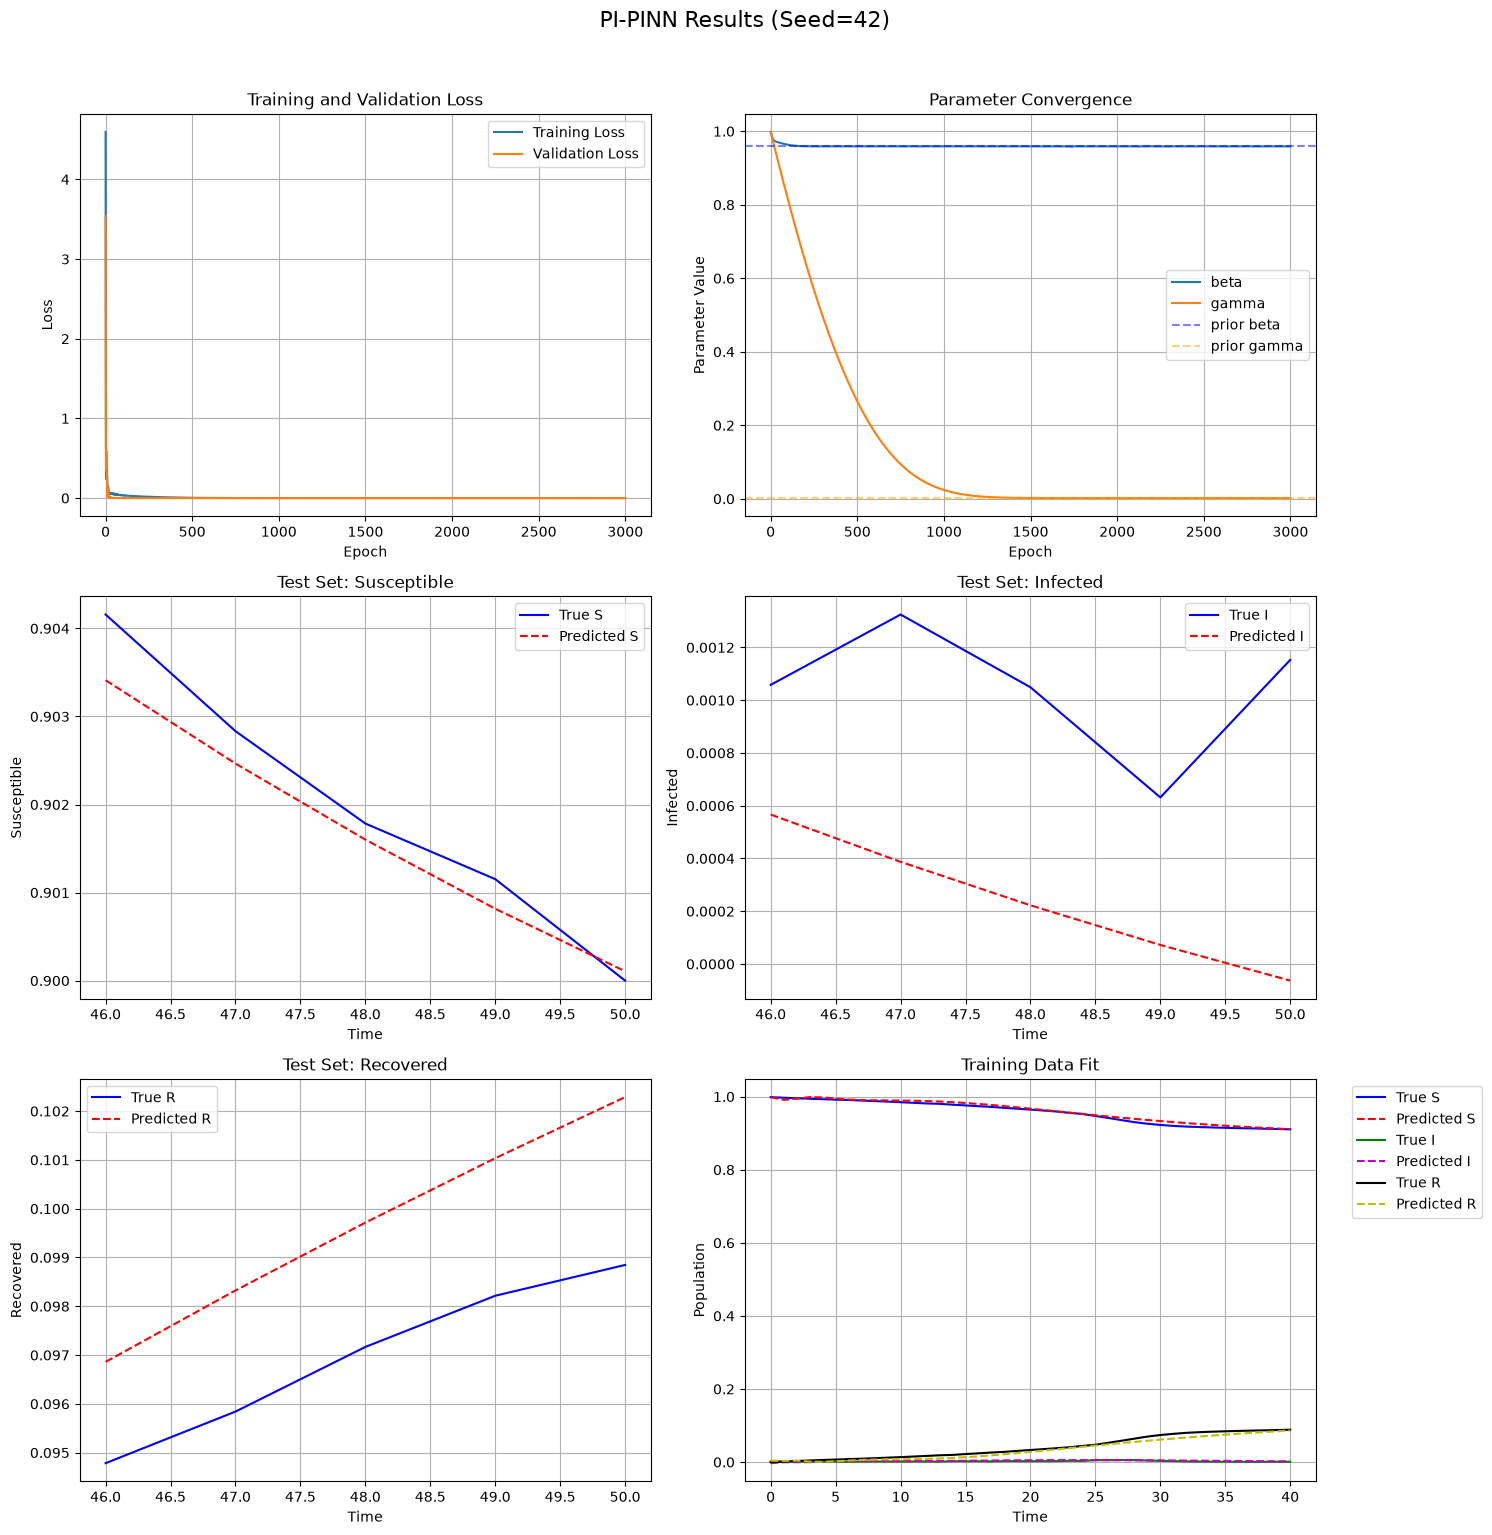

In [9]:
def plot_pipinn_results(t_train, S_train, I_train, R_train,
                         t_test, S_test, I_test, R_test,
                         train_losses, val_losses, parameter_estimates,
                         test_predictions, seed):
    fig, axes = plt.subplots(3, 2, figsize=(15, 15))
    plt.suptitle(f'PI-PINN Results (Seed={seed})', y=1.02, fontsize=16)

    axes[0, 0].plot(train_losses, label='Training Loss')
    axes[0, 0].plot(val_losses, label='Validation Loss')
    axes[0, 0].set_xlabel('Epoch'); axes[0, 0].set_ylabel('Loss')
    axes[0, 0].set_title('Training and Validation Loss')
    axes[0, 0].legend(); axes[0, 0].grid(True)

    axes[0, 1].plot(parameter_estimates['beta'], label='beta')
    axes[0, 1].plot(parameter_estimates['gamma'], label='gamma')
    axes[0, 1].axhline(y=MU_BETA_BASE, color='blue', linestyle='--', alpha=0.5, label='prior beta')
    axes[0, 1].axhline(y=MU_GAMMA_BASE, color='orange', linestyle='--', alpha=0.5, label='prior gamma')
    axes[0, 1].set_xlabel('Epoch'); axes[0, 1].set_ylabel('Parameter Value')
    axes[0, 1].set_title('Parameter Convergence'); axes[0, 1].legend(); axes[0, 1].grid(True)

    axes[1, 0].plot(t_test, S_test, 'b-', label='True S')
    axes[1, 0].plot(t_test, test_predictions['S'], 'r--', label='Predicted S')
    axes[1, 0].set_xlabel('Time'); axes[1, 0].set_ylabel('Susceptible')
    axes[1, 0].set_title('Test Set: Susceptible'); axes[1, 0].legend(); axes[1, 0].grid(True)

    axes[1, 1].plot(t_test, I_test, 'b-', label='True I')
    axes[1, 1].plot(t_test, test_predictions['I'], 'r--', label='Predicted I')
    axes[1, 1].set_xlabel('Time'); axes[1, 1].set_ylabel('Infected')
    axes[1, 1].set_title('Test Set: Infected'); axes[1, 1].legend(); axes[1, 1].grid(True)

    axes[2, 0].plot(t_test, R_test, 'b-', label='True R')
    axes[2, 0].plot(t_test, test_predictions['R'], 'r--', label='Predicted R')
    axes[2, 0].set_xlabel('Time'); axes[2, 0].set_ylabel('Recovered')
    axes[2, 0].set_title('Test Set: Recovered'); axes[2, 0].legend(); axes[2, 0].grid(True)

    model_ = pipinn_model
    model_.eval()
    with torch.no_grad():
        t_train_tensor_ = to_tensor(t_train, device)
        out_train = model_(t_train_tensor_)
        S_train_pred = out_train[:, 0:1].cpu().numpy()
        I_train_pred = out_train[:, 1:2].cpu().numpy()
        R_train_pred = out_train[:, 2:3].cpu().numpy()

    axes[2, 1].plot(t_train, S_train, 'b-', label='True S')
    axes[2, 1].plot(t_train, S_train_pred, 'r--', label='Predicted S')
    axes[2, 1].plot(t_train, I_train, 'g-', label='True I')
    axes[2, 1].plot(t_train, I_train_pred, 'm--', label='Predicted I')
    axes[2, 1].plot(t_train, R_train, 'k-', label='True R')
    axes[2, 1].plot(t_train, R_train_pred, 'y--', label='Predicted R')
    axes[2, 1].set_xlabel('Time'); axes[2, 1].set_ylabel('Population')
    axes[2, 1].set_title('Training Data Fit')
    axes[2, 1].legend(bbox_to_anchor=(1.05, 1), loc='upper left'); axes[2, 1].grid(True)

    plt.tight_layout()
    plt.show()
    return fig


fig = plot_pipinn_results(
    t_train_set, data_S_train_set, data_I_train_set, data_R_train_set,
    t_test_set, S_test_np, I_test_np, R_test_np,
    train_losses, val_losses, parameter_estimates,
    results['predictions'], seed
)


## 10. Summary Table (for paper reporting)

In [10]:
summary_df = pd.DataFrame([{
    'Model': 'PI-PINN (Ours)',
    'Seed': seed,
    'beta_est': results['beta'],
    'gamma_est': results['gamma'],
    'R0_est': results['R0'],
    'RMSE_joint': results['rmse_joint'],
    'MAE_S': results['mae']['S'],
    'MAE_I': results['mae']['I'],
    'MAE_R': results['mae']['R'],
    'R2_S': results['r2']['S'],
    'R2_I': results['r2']['I'],
    'R2_R': results['r2']['R'],
    'AIC': results['aic'],
    'BIC': results['bic'],
}])
summary_df


,Model,Seed,beta_est,gamma_est,R0_est,RMSE_joint,MAE_S,MAE_I,MAE_R,R2_S,R2_I,R2_R,AIC,BIC
0,PI-PINN (Ours),42,0.958959,0.002044,469.222896,0.00287,0.000348,0.000806,0.002673,0.915922,-12.77024,-2.291678,-54.53318,-55.314305
